# 3D Computer Vision Project — Demo

End-to-end walkthrough of the pipeline:
1. Checkerboard corner detection
2. Camera calibration (Zhang's method) — intrinsics `K` + per-view extrinsics `(rvec, tvec)`
3. Object detection (cubes, targets, robot) in a scene image
4. Top-down 2D world view of detected objects

## Initialization

In [2]:
import os, glob
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

from checkerboard_detection import _find_checkerboard_corners
from camera_calibration import calibrate, _build_object_points, _project_points
from object_detection import _detect_cubes, _detect_target_locations, _detect_robot, CUBE_TOP_HEIGHT_CM

CALIBRATION_DIR = 'test-images/set2/calibration'
SCENE_DIR = 'test-images/set2/images'
PATTERN_SIZE = (8, 6)
SQUARE_SIZE_CM = 4.0

## 1. Checkerboard detection

Detect the 8x6 interior-corner grid in each calibration image using OpenCV's SB detector, with sub-pixel refinement.

Loaded 3 calibration image(s) from test-images/set2/calibration


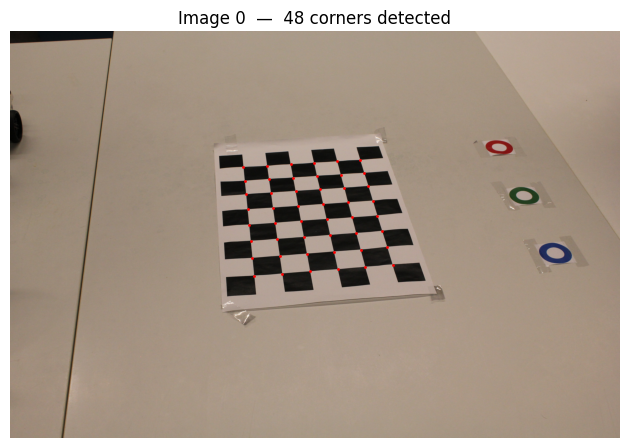

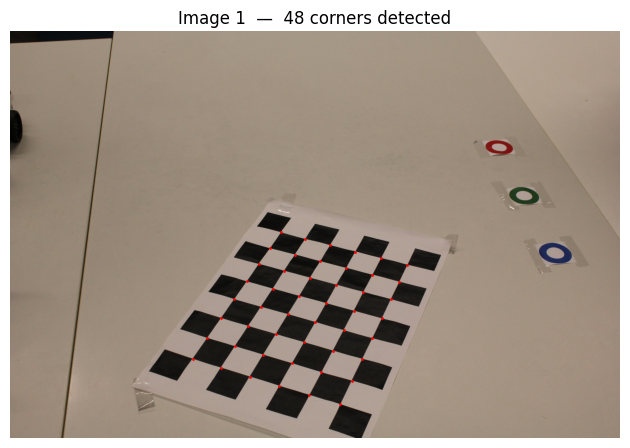

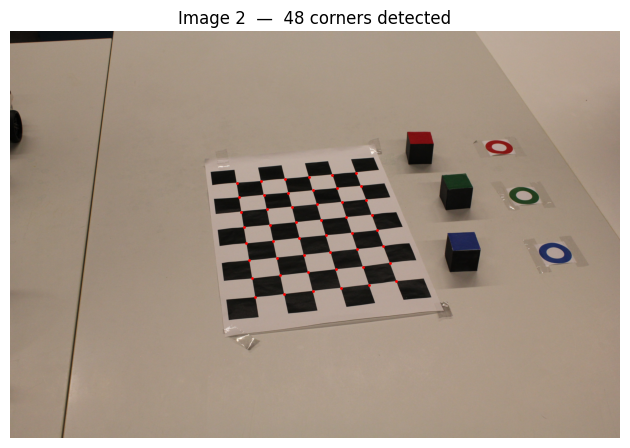

In [3]:
calib_paths  = sorted(glob.glob(os.path.join(CALIBRATION_DIR, '*.png')))
calib_images = [Image.open(p) for p in calib_paths]
print(f'Loaded {len(calib_images)} calibration image(s) from {CALIBRATION_DIR}')

for i, image in enumerate(calib_images):
    gray = np.array(image.convert('L'), dtype=np.uint8)
    try:
        corners, _ = _find_checkerboard_corners(gray, PATTERN_SIZE)
    except RuntimeError:
        print(f'Corners not detected in image {i}')
        continue
    plt.figure()
    plt.imshow(image)
    plt.scatter(corners[:, 0], corners[:, 1], s=4, c='red', marker='.')
    plt.title(f'Image {i}  —  {len(corners)} corners detected')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## 2. Camera calibration (Zhang's method)

Pipeline: DLT homography per view -> Zhang's closed-form K (with EXIF fallback if the closed-form solution is implausible) -> per-view extrinsics -> joint LM refinement.

In [4]:
calibration = calibrate(calib_images, PATTERN_SIZE, SQUARE_SIZE_CM)

K      = calibration['K']
rvecs  = calibration['rvecs']
tvecs  = calibration['tvecs']
w, h   = calibration['image_size']

print('\n=== Calibration result ===')
print(f'Image size:    {w} x {h}')
print(f'Intrinsics K:\n{np.array2string(K, precision=2)}')
print(f'Focal length:  fx={K[0, 0]:.1f}, fy={K[1, 1]:.1f}')
print(f'Principal pt:  cx={K[0, 2]:.1f}, cy={K[1, 2]:.1f}')
print(f'Views used:    {len(rvecs)}')

[calibrate] Zhang's K:
[[ 6.7e+03  5.0e+03  2.8e+03]
 [ 0.0e+00  2.8e+02 -3.8e+03]
 [ 0.0e+00  0.0e+00  1.0e+00]]
[calibrate] Using EXIF-based K estimate
[calibrate] RMS reprojection error: 1.0657 px (3 views)

=== Calibration result ===
Image size:    5184 x 3456
Intrinsics K:
[[7.63e+03 0.00e+00 2.71e+03]
 [0.00e+00 7.96e+03 1.04e+03]
 [0.00e+00 0.00e+00 1.00e+00]]
Focal length:  fx=7626.0, fy=7958.0
Principal pt:  cx=2711.4, cy=1036.8
Views used:    3


### Reprojection + world frame on each view
Green circles = detected corners. Red x = reprojected (via refined `K, R, t`). Red/green/blue lines = world X/Y/Z axes at the board origin.

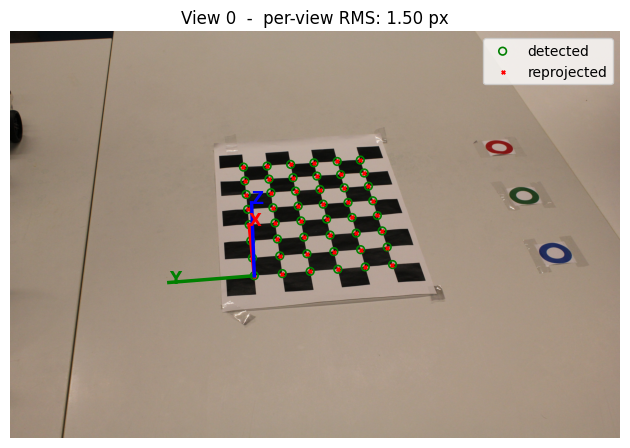

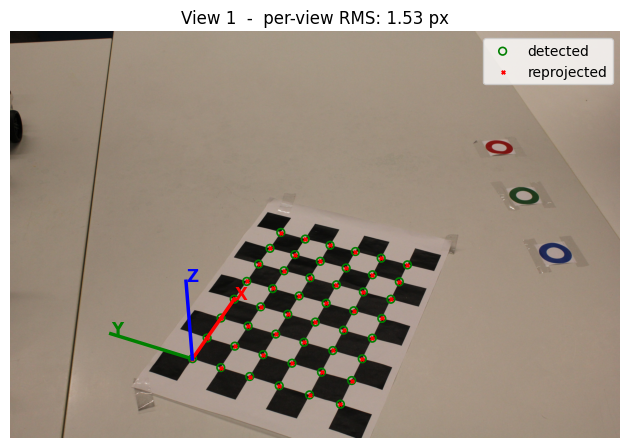

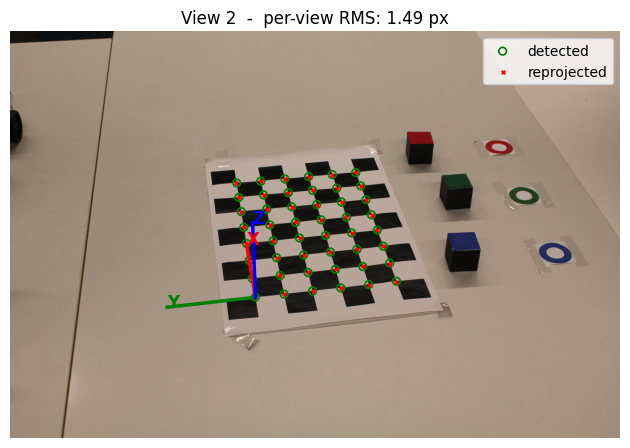

In [5]:
object_points  = _build_object_points(PATTERN_SIZE, SQUARE_SIZE_CM)
axis_length_cm = 3 * SQUARE_SIZE_CM
world_axes = np.array([[0, 0, 0],
                       [axis_length_cm, 0, 0],
                       [0, axis_length_cm, 0],
                       [0, 0, axis_length_cm]], dtype=np.float64)

for i, pil_image in enumerate(calib_images):
    gray = np.array(pil_image.convert('L'), dtype=np.uint8)
    try:
        detected_corners, _ = _find_checkerboard_corners(gray, PATTERN_SIZE)
    except RuntimeError:
        continue

    projected_corners = _project_points(object_points.astype(np.float64),
                                        K, rvecs[i], tvecs[i])
    per_view_rms = np.sqrt(np.mean(
        np.sum((projected_corners - detected_corners) ** 2, axis=1)))
    axes_image = _project_points(world_axes, K, rvecs[i], tvecs[i])
    origin_px  = axes_image[0]

    plt.figure()
    plt.imshow(pil_image)
    plt.scatter(detected_corners[:, 0], detected_corners[:, 1], s=30,
                facecolors='none', edgecolors='green', linewidths=1.2, label='detected')
    plt.scatter(projected_corners[:, 0], projected_corners[:, 1], s=6,
                c='red', marker='x', label='reprojected')
    for axis_index, color, label in [(1, 'red', 'X'), (2, 'green', 'Y'), (3, 'blue', 'Z')]:
        end_px = axes_image[axis_index]
        plt.plot([origin_px[0], end_px[0]], [origin_px[1], end_px[1]],
                 color=color, linewidth=2.5)
        plt.text(end_px[0], end_px[1], label, color=color,
                 fontsize=12, fontweight='bold')
    plt.title(f'View {i}  -  per-view RMS: {per_view_rms:.2f} px')
    plt.legend(loc='upper right')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## 3. Object detection in a scene image

Reuse the last calibration view's pose `(R, t)` as the scene pose (same camera position). Then run HSV-based blob detection for cubes (solid blobs, top face at z=4 cm), targets (rings with holes, on the floor), and the robot's yellow front / purple back markers.

In [6]:
R_scene, _ = cv2.Rodrigues(calibration['rvecs'][-1])
t_scene    = calibration['tvecs'][-1].ravel()

scene_paths = sorted(glob.glob(os.path.join(SCENE_DIR, '*.png')))
scene_image = Image.open(scene_paths[0])
bgr = cv2.cvtColor(np.array(scene_image), cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

cubes   = _detect_cubes(hsv, calibration, R_scene, t_scene)
targets = _detect_target_locations(hsv, calibration, R_scene, t_scene)
try:
    robot = _detect_robot(hsv, calibration, R_scene, t_scene)
except RuntimeError as e:
    print(f'Robot detection failed: {e}')
    robot = None

print(f'\n=== Detection on {os.path.basename(scene_paths[0])} ===')
print(f'Cubes ({len(cubes)}):')
for color, xyz in cubes.items():
    print(f'  {color:6s}: ({xyz[0]:+7.1f}, {xyz[1]:+7.1f}, {xyz[2]:+5.1f}) cm')
print(f'Targets ({len(targets)}):')
for color, xyz in targets.items():
    print(f'  {color:6s}: ({xyz[0]:+7.1f}, {xyz[1]:+7.1f}, {xyz[2]:+5.1f}) cm')
if robot is not None:
    print(f"Robot pos: ({robot['pos'][0]:+7.1f}, {robot['pos'][1]:+7.1f}, "
          f"{robot['pos'][2]:+5.1f}) cm, heading: {np.degrees(robot['heading']):+6.1f} deg")


=== Detection on image0000.png ===
Cubes (3):
  red   : (  +30.3,   -31.5,  +4.0) cm
  green : (  +16.7,   -33.8,  +4.0) cm
  blue  : (   +2.0,   -30.2,  +4.0) cm
Targets (3):
  red   : (  +31.6,   -46.5,  +0.0) cm
  green : (  +16.9,   -45.5,  +0.0) cm
  blue  : (   +2.2,   -44.8,  +0.0) cm
Robot pos: (  +15.7,    -8.2,  +9.0) cm, heading: -106.1 deg


### Detections overlaid on the scene image
World points projected back to pixels using the scene pose. Cubes = filled squares; targets = open circles; robot = yellow front / magenta back markers with a line between them.

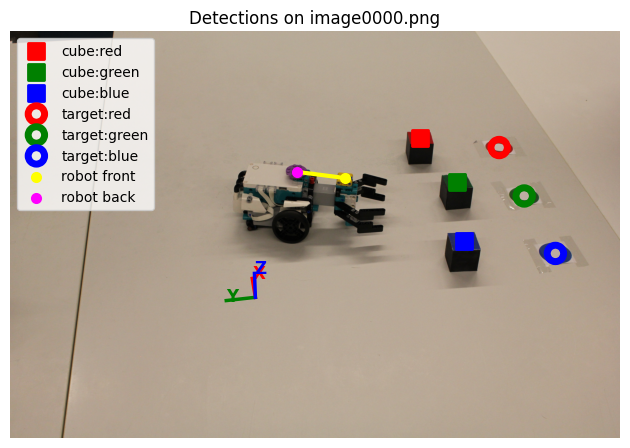

In [7]:
def world_to_pixel(world_xyz):
    camera_pt = R_scene @ np.asarray(world_xyz) + t_scene
    image_pt  = K @ camera_pt
    return image_pt[0] / image_pt[2], image_pt[1] / image_pt[2]

plt.figure()
plt.imshow(scene_image)

origin_px = world_to_pixel([0.0, 0.0, 0.0])
for i, (axis_vec, color, label) in enumerate([
        ([SQUARE_SIZE_CM, 0, 0], 'red',   'X'),
        ([0, SQUARE_SIZE_CM, 0], 'green', 'Y'),
        ([0, 0, SQUARE_SIZE_CM], 'blue',  'Z')]):
    end_px = world_to_pixel(axis_vec)
    plt.plot([origin_px[0], end_px[0]], [origin_px[1], end_px[1]],
             color=color, linewidth=2.5, zorder=i+2)
    plt.text(end_px[0], end_px[1], label, color=color,
             fontsize=12, fontweight='bold', zorder=i+2)

for color, xyz in cubes.items():
    u, v = world_to_pixel(xyz)
    plt.scatter(u, v, s=140, facecolors=color, edgecolors=color,
                linewidths=2.0, marker='s', label=f'cube:{color}')
for color, xyz in targets.items():
    u, v = world_to_pixel(xyz)
    plt.scatter(u, v, s=140, facecolors='none', edgecolors=color,
                linewidths=5.0, marker='o', label=f'target:{color}')
if robot is not None:
    uf, vf = world_to_pixel(robot['front'])
    ub, vb = world_to_pixel(robot['back'])
    plt.plot([ub, uf], [vb, vf], color='yellow', linewidth=3, zorder=1)
    plt.scatter(uf, vf, s=120, c='yellow', marker='.', linewidths=2.5,
                zorder=1, label='robot front')
    plt.scatter(ub, vb, s=120, c='magenta', marker='.', linewidths=2.5,
                zorder=2, label='robot back')

plt.title(f"Detections on {os.path.basename(scene_paths[0])}")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Top-down world view
Plotted in real-world (X, Y) cm. Each object's `(X, Y)` is the metric position at its actual height plane: cubes at z=4, targets at z=0, robot markers at their physical heights.

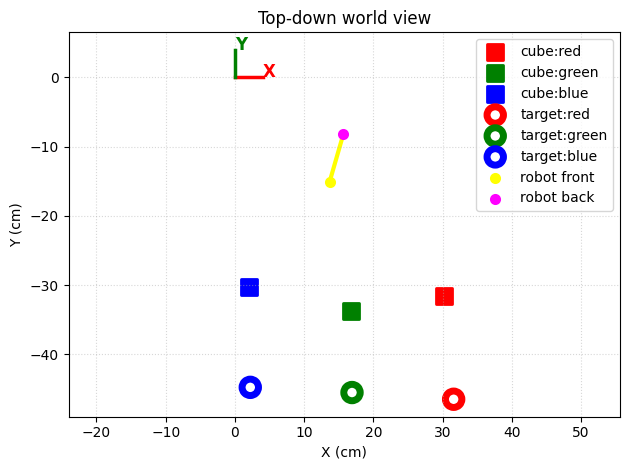

In [9]:
plt.figure()

plt.plot([0, SQUARE_SIZE_CM], [0, 0], color='red',   linewidth=2.5)
plt.plot([0, 0], [0, SQUARE_SIZE_CM], color='green', linewidth=2.5)
plt.text(SQUARE_SIZE_CM, 0, 'X', color='red',   fontsize=12, fontweight='bold')
plt.text(0, SQUARE_SIZE_CM, 'Y', color='green', fontsize=12, fontweight='bold')

for color, xyz in cubes.items():
    plt.scatter(xyz[0], xyz[1], s=140, facecolors=color, edgecolors=color,
                linewidths=2.0, marker='s', label=f'cube:{color}')
for color, xyz in targets.items():
    plt.scatter(xyz[0], xyz[1], s=140, facecolors='none', edgecolors=color,
                linewidths=5.0, marker='o', label=f'target:{color}')
if robot is not None:
    bx, by, _  = robot['back']
    fx_, fy_, _ = robot['front']
    plt.plot([bx, fx_], [by, fy_], color='yellow', linewidth=3, zorder=1)
    plt.scatter(fx_, fy_, s=120, c='yellow', marker='.', linewidths=2.5,
                zorder=1, label='robot front')
    plt.scatter(bx, by, s=120, c='magenta', marker='.', linewidths=2.5,
                zorder=2, label='robot back')

plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Top-down world view')
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()